# Homework3   

# Loading libraries

In [1]:
library(ArchR)
library(parallel)
library(Seurat)

library(pryr)
addArchRThreads(threads=30)
set.seed(1)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

# Importing data and generate arrowfiles

In [2]:
addArchRGenome("mm10")

BSgenome for mm10 not installed! Now installing by the following:
	BiocManager::install("BSgenome.Mmusculus.UCSC.mm10")

'getOption("repos")' replaces Bioconductor standard repositories, see
'?repositories' for details

replacement repositories:
    CRAN: https://cloud.r-project.org


Bioconductor version 3.15 (BiocManager 1.30.18), R 4.2.1 (2022-06-23)

Installing package(s) 'BSgenome.Mmusculus.UCSC.mm10'

Installation paths not writeable, unable to update packages
  path: /usr/lib/R/library
  packages:
    cluster, MASS, spatial

Setting default genome to Mm10.



In [11]:
setwd("~/scRNA/arrowfiles/tutorialmm10")

inputdir <- "~/scRNA/data/scATAC"
first_name <- list.files(inputdir,"tsv.gz$")
sample_name <- gsub(".fragments.tsv.gz","",first_name)
FragmentFiles <- paste(inputdir,first_name,sep="/")
names(FragmentFiles) <- sample_name

In [12]:
print(FragmentFiles)

                                       beads_4000_1 
"~/scRNA/data/scATAC/beads_4000_1.fragments.tsv.gz" 


In [13]:
ArrowFiles <- createArrowFiles(
 inputFiles = FragmentFiles,
 minFrags = 1000, #Dont","set","this","too","high","because","you","can","always","increase","later
 minTSS = 4,
 addTileMat = TRUE,
 addGeneScoreMat = TRUE,
 threads = 36,
 force = T
)

Using GeneAnnotation set by addArchRGenome(Mm10)!

Using GeneAnnotation set by addArchRGenome(Mm10)!

ArchR logging to : ArchRLogs/ArchR-createArrows-cb8115c96f4-Date-2022-08-29_Time-02-53-36.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

2022-08-29 02:53:36 : Batch Execution w/ safelapply!, 0 mins elapsed.

(beads_4000_1 : 1 of 1) Determining Arrow Method to use!

2022-08-29 02:53:36 : (beads_4000_1 : 1 of 1) Reading In Fragments from inputFiles (readMethod = tabix), 0 mins elapsed.

2022-08-29 02:53:36 : (beads_4000_1 : 1 of 1) Tabix Bed To Temporary File, 0 mins elapsed.

2022-08-29 02:58:25 : (beads_4000_1 : 1 of 1) Successful creation of Temporary File, 4.817 mins elapsed.

2022-08-29 02:58:25 : (beads_4000_1 : 1 of 1) Creating ArrowFile From Temporary File, 4.817 mins elapsed.

2022-08-29 02:59:27 : (beads_4000_1 : 1 of 1) Successful creation of Arrow File, 5.849 mins elapsed.

2022-08-29 03:00:36 : (beads_4000_1 : 1 of 1) CellStats : N

# RESPAWN 1

Had server issues. These are respawn point to restart the analyses from saved checkpoint files.

In [1]:
# So I don't have to make arrowfile again
library(ArchR)
library(parallel)
library(Seurat)

library(pryr)
addArchRThreads(threads=30)
set.seed(1)

setwd("~/scRNA/arrowfiles/tutorialmm10")
ArrowFiles <- "beads_4000_1.arrow"


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

# Filtering

## Find doublets

In [4]:
doubScores <- addDoubletScores(
    input = ArrowFiles, 
    k = 10, #Refers","to","how","many","cells","near","a "pseudo-doublet" to","count. 
    knnMethod = "UMAP", #Refers","to","the","embedding","to","use","for","nearest","neighbor","search","with","doublet","projection. 
    LSIMethod = 1,
    threads = 36
    )

ArchR logging to : ArchRLogs/ArchR-addDoubletScores-863a5b0d1c59-Date-2022-08-29_Time-13-48-31.log
If there is an issue, please report to github with logFile!

2022-08-29 13:48:32 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-08-29 13:48:32 : beads_4000_1 (1 of 1) :  Computing Doublet Statistics, 0 mins elapsed.

beads_4000_1 (1 of 1) : UMAP Projection R^2 = 0.99882

beads_4000_1 (1 of 1) : UMAP Projection R^2 = 0.99882

ArchR logging successful to : ArchRLogs/ArchR-addDoubletScores-863a5b0d1c59-Date-2022-08-29_Time-13-48-31.log



## Create ArchR object

In [5]:
addArchRGenome("mm10")

Setting default genome to Mm10.



In [6]:
raw_proj <- ArchRProject(
    ArrowFiles = ArrowFiles,
    outputDirectory = "outputs",
    copyArrows = FALSE
)
raw_proj

Using GeneAnnotation set by addArchRGenome(Mm10)!

Using GeneAnnotation set by addArchRGenome(Mm10)!

Validating Arrows...

Getting SampleNames...

1 


Getting Cell Metadata...

1 


Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ __

class: ArchRProject 
outputDirectory: /home/metabo/scRNA/arrowfiles/tutorialmm10/outputs 
samples(1): beads_4000_1
sampleColData names(1): ArrowFiles
cellColData names(15): Sample TSSEnrichment ... DoubletEnrichment
  BlacklistRatio
numberOfCells(1): 8593
medianTSS(1): 10.567
medianFrags(1): 16163

## TSS enrichment distribution and fragment number distribution

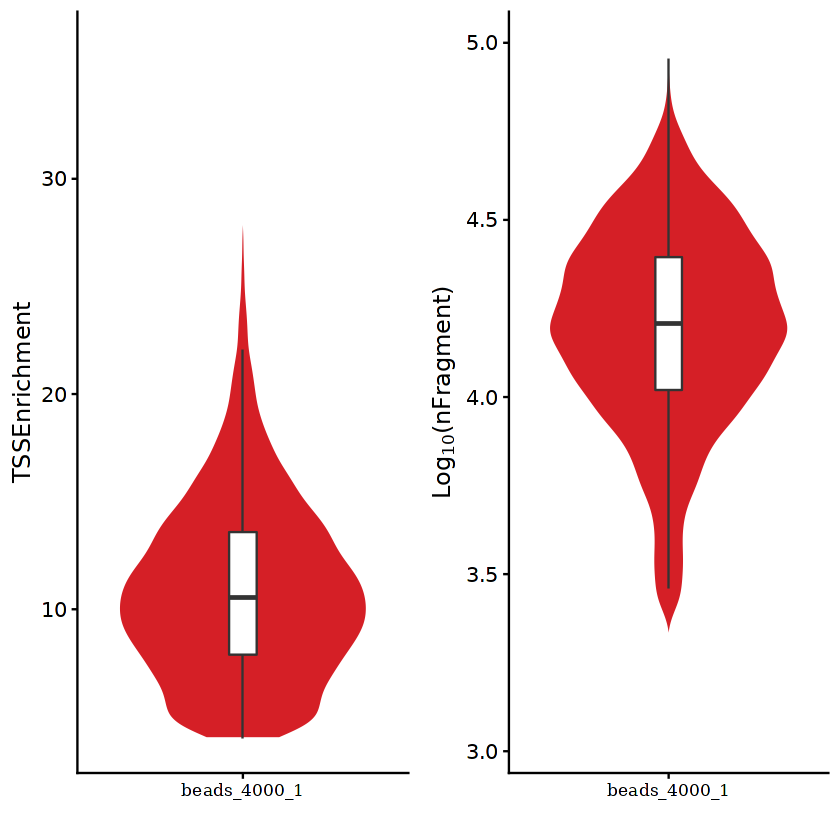

In [7]:
library(cowplot)
metadata <- as.data.frame(raw_proj@cellColData)
colours <- ArchR:::paletteDiscrete( values = unique(metadata$Sample))

P1<- ggplot(metadata, aes(x = Sample, y = TSSEnrichment, fill=Sample)) + 
  geom_violin(trim=TRUE,color="white",show.legend = F) +
  geom_boxplot(width=0.1,position=position_dodge(0.9),show.legend = F,fill="white",outlier.size = 0,outlier.stroke = 0)+
  scale_fill_manual(values = colours)+
  theme_cowplot()+
  theme(axis.text.x=element_text(colour="black",family="Times",size=10))+
  ylab("TSSEnrichment")+xlab("")

P2<- ggplot(metadata, aes(x = Sample, y = log10(nFrags), fill=Sample)) + 
  geom_violin(trim=TRUE,color="white",show.legend = F) +
  geom_boxplot(width=0.1,position=position_dodge(0.9),show.legend = F,fill="white",outlier.size = 0,outlier.stroke = 0)+
  scale_fill_manual(values = colours)+
  theme_cowplot()+
  theme(axis.text.x=element_text(colour="black",family="Times",size=10))+
  ylab(expression(Log[10]*paste("(","nFragment",")",sep = "")))+xlab("")

P <- do.call(plot_grid,c(list(P1,P2),ncol=2,align = "h"))
P


> Seems mice have different distribution of TSS enrichment from humans do. Probably do not want to filter out those below 10  
> Good cutoff for nFragment seems to be ~3900

## Filter based on nFrags

In [8]:
proj <- raw_proj[which(raw_proj$nFrags > 3900),]

## Filter based on doublets

> ratio 1 corresponds to 5% filtered  
> formula is num filtered = ratio * total num * 0.05    

In [9]:
proj <- filterDoublets(proj, filterRatio = 1)

Filtering 685 cells from ArchRProject!

	beads_4000_1 : 685 of 8281 (8.3%)



# Dimension Reduction

## Iterative LSI

In [11]:
proj <- addIterativeLSI(
    ArchRProj = proj,
    useMatrix = "TileMatrix",
    iterations = 5,
    clusterParams = list(
        resolution = c(0.2),
        sampleCells = 1000, # Downsample using 1000 cells
        n.start = 10
    ),
    varFeatures = 25000, # Number of features to use
    dimsToUse = 1:30, 
    force = T,
    threads = 36
)

mem_used()

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-863a3f7cec86-Date-2022-08-29_Time-13-54-15.log
If there is an issue, please report to github with logFile!

2022-08-29 13:54:15 : Computing Total Across All Features, 0.001 mins elapsed.

2022-08-29 13:54:16 : Computing Top Features, 0.013 mins elapsed.

###########
2022-08-29 13:54:17 : Running LSI (1 of 5) on Top Features, 0.034 mins elapsed.
###########

2022-08-29 13:54:17 : Creating Partial Matrix, 0.034 mins elapsed.

2022-08-29 13:54:39 : Computing LSI, 0.387 mins elapsed.

2022-08-29 13:55:02 : Identifying Clusters, 0.77 mins elapsed.

2022-08-29 13:55:04 : Identified 9 Clusters, 0.809 mins elapsed.

2022-08-29 13:55:04 : Saving LSI Iteration, 0.809 mins elapsed.

2022-08-29 13:55:20 : Creating Cluster Matrix on the total Group Features, 1.075 mins elapsed.

2022-08-29 13:55:44 : Computing Variable Features, 1.478 mins elapsed.

###########
2022-08-29 13:55:44 : Running LSI (2 of 5) on Variable Features, 1.4

732 MB

> Looked at pdf output of iterations. Honestly can't tell which is good without some prior knowledge. The first iteration gives 13 clusters, while the rest give 12. They are all small and dispersed. Connection exists among some of them.

# Visualization

## Add UMAP

In [12]:
proj <- addUMAP(
    ArchRProj = proj,
    reducedDims = "IterativeLSI",
    name = "UMAP",
    nNeighbors = 30,
    minDist = 0.5,
    metric = "cosine", 
    force = T,
    threads = 36
)
mem_used()

14:00:26 UMAP embedding parameters a = 0.583 b = 1.334

14:00:26 Read 7596 rows and found 30 numeric columns

14:00:26 Using Annoy for neighbor search, n_neighbors = 30

14:00:26 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:00:27 Writing NN index file to temp file /tmp/RtmpxrcDGw/file863a7156af27

14:00:27 Searching Annoy index using 20 threads, search_k = 3000

14:00:28 Annoy recall = 100%

14:00:29 Commencing smooth kNN distance calibration using 20 threads
 with target n_neighbors = 30

14:00:30 Initializing from normalized Laplacian + noise (using irlba)

14:00:31 Commencing optimization for 500 epochs, with 320764 positive edges

14:00:41 Optimization finished

14:00:41 Creating temp model dir /tmp/RtmpxrcDGw/dir863a61c5978f

14:00:41 Creating dir /tmp/Rtmpx

733 MB

## Add clusters

In [13]:
proj <- addClusters(
    input = proj,
    reducedDims = "IterativeLSI",
    method = "Seurat",
    name = "Clusters",
    maxClusters = 35,
    resolution = 0.8,
    force = T,
    threads = 36
)

ArchR logging to : ArchRLogs/ArchR-addClusters-863a6d3c8346-Date-2022-08-29_Time-14-00-43.log
If there is an issue, please report to github with logFile!

2022-08-29 14:00:43 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.002 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7596
Number of edges: 306851

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9093
Number of communities: 18
Elapsed time: 0 seconds


2022-08-29 14:00:53 : Testing Biased Clusters, 0.174 mins elapsed.

2022-08-29 14:00:53 : Testing Outlier Clusters, 0.175 mins elapsed.

2022-08-29 14:00:53 : Assigning Cluster Names to 18 Clusters, 0.175 mins elapsed.

2022-08-29 14:00:53 : Finished addClusters, 0.177 mins elapsed.



## Dimplot

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-863a7b44cee7-Date-2022-08-29_Time-14-00-53.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-863a7b44cee7-Date-2022-08-29_Time-14-00-53.log

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-863a13aed44f-Date-2022-08-29_Time-14-00-54.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-863a13aed44f-Date-2022-08-29_Time-14-00-54.log



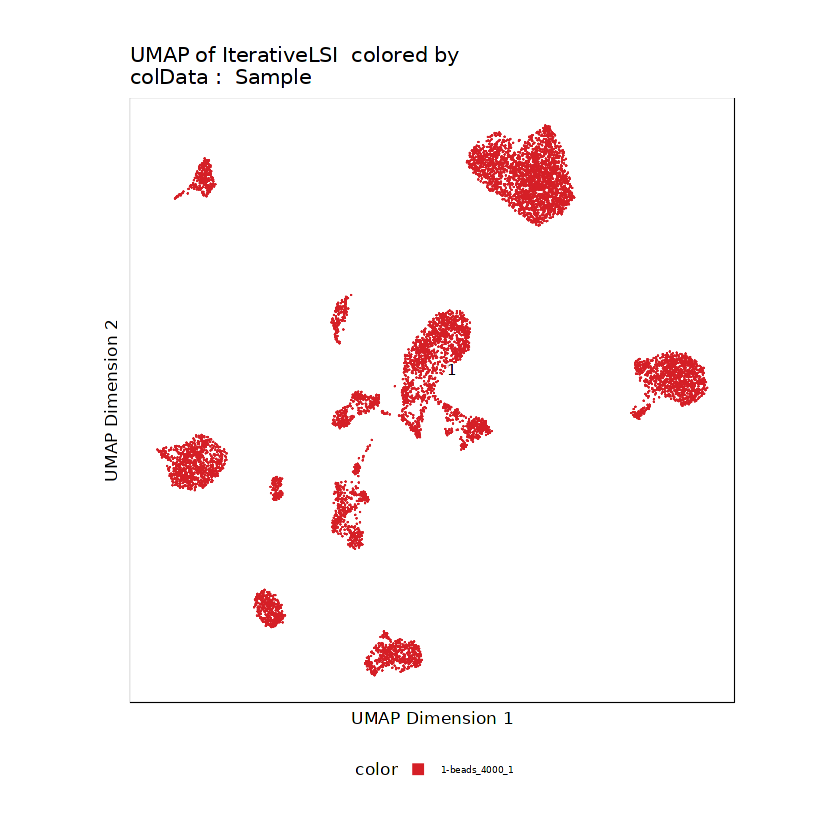

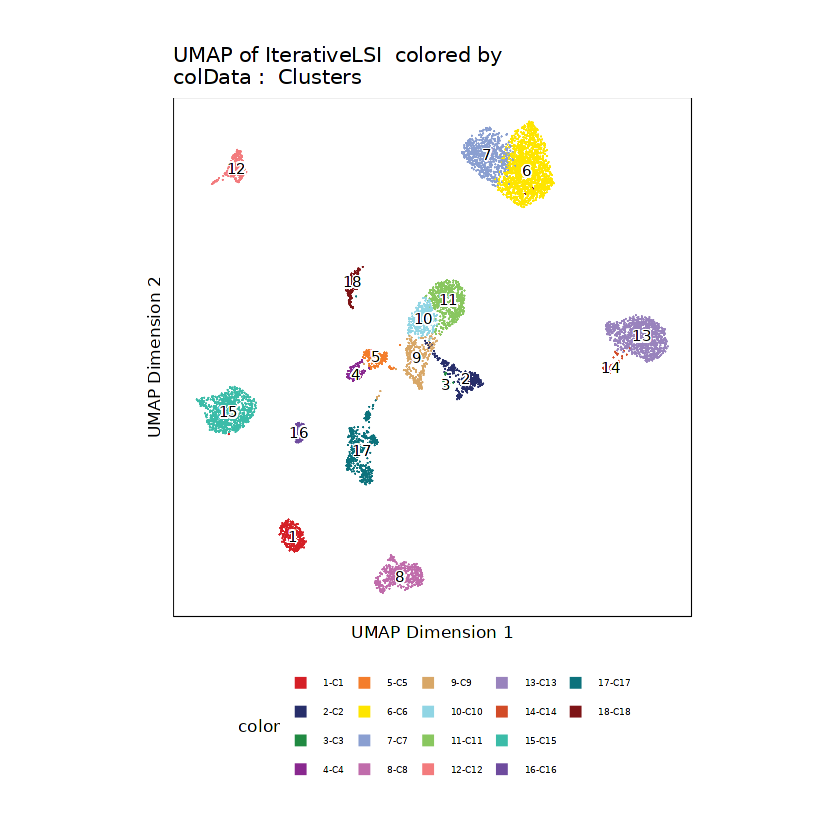

In [14]:
p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Sample", embedding = "UMAP")
p2 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Clusters", embedding = "UMAP")

p1
p2

# Get markers genes for each cluster

## Noise removal

In [15]:
proj <- addImputeWeights(
  ArchRProj = proj,
  reducedDims = "IterativeLSI",
  dimsToUse = NULL,
  scaleDims = NULL,
  corCutOff = 0.75,
  td = 3,
  ka = 4,
  sampleCells = 1000,
  nRep = 2,
  k = 15,
  epsilon = 1,
  useHdf5 = TRUE,
  randomSuffix = FALSE,
  threads = getArchRThreads(),
  seed = 1,
  verbose = TRUE,
  logFile = createLogFile("addImputeWeights")
)

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-863a66d090c5-Date-2022-08-29_Time-14-00-57.log
If there is an issue, please report to github with logFile!

2022-08-29 14:00:57 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.



## Get marker genes

> The gene score matrix was calculated when creating the archr object.

In [16]:
markersGS <- getMarkerFeatures(
    ArchRProj = proj,
    useMatrix = "GeneScoreMatrix",
    groupBy = "Clusters",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-863a57c4ff38-Date-2022-08-29_Time-14-01-08.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2022-08-29 14:01:08 : Matching Known Biases, 0.001 mins elapsed.

###########
2022-08-29 14:03:50 : Completed Pairwise Tests, 2.692 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-863a57c4ff38-Date-2022-08-29_Time-14-01-08.log



In [17]:
markerList <- getMarkers(markersGS)
markerList$C2
for (i in names(markerList)){if(dim(markerList[[i]])[1] > 0){markerList[[i]]$cluster <- i}}
b <- do.call(rbind,markerList)
write.table(b,file="cortex_filtered_markergene_list.tsv",quote=F,row.names=F,sep="\t")

DataFrame with 2902 rows and 9 columns
      seqnames     start       end  strand          name     idx    Log2FC
         <Rle>   <array>   <array> <array>       <array> <array> <numeric>
13152     chr2 169633646 169913087       1         Tshz2    1899   2.79795
6959     chr14 119138265 119869815       1        Hs6st3     845   1.97277
276       chr1  56971334  56793981       2         Satb2     276   2.46368
21032     chr8  29219636  28646717       2         Unc5d     267   2.07014
375       chr1  71414910  71243090       2        Abca12     375   2.46406
...        ...       ...       ...     ...           ...     ...       ...
21105     chr8  43699491  43650309       2        Adam34     340  0.557567
3686     chr11  95076811  95044475       2         Itga3    1181  0.896383
6576     chr14  55491093  55508264       1       Carmil3     462  0.580719
3125     chr11  67120080  67112461       2 2310065F04Rik     620  0.590944
11647     chr2  32450457  32455476       1         Naif1     

## Visualizing top genes

In [18]:
# Just choosing the 4 top genes to look at
markerGenes <- c(
    "Tshz2", 
    "Hs6st3",
    "Satb2",
    "Unc5d"
)

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-863a4d9b8dfd-Date-2022-08-29_Time-14-03-53.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2022-08-29 14:03:53 : 

1 


Imputing Matrix

Using weights on disk

Using weights on disk

Plotting Embedding

1 
2 
3 
4 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-863a4d9b8dfd-Date-2022-08-29_Time-14-03-53.log



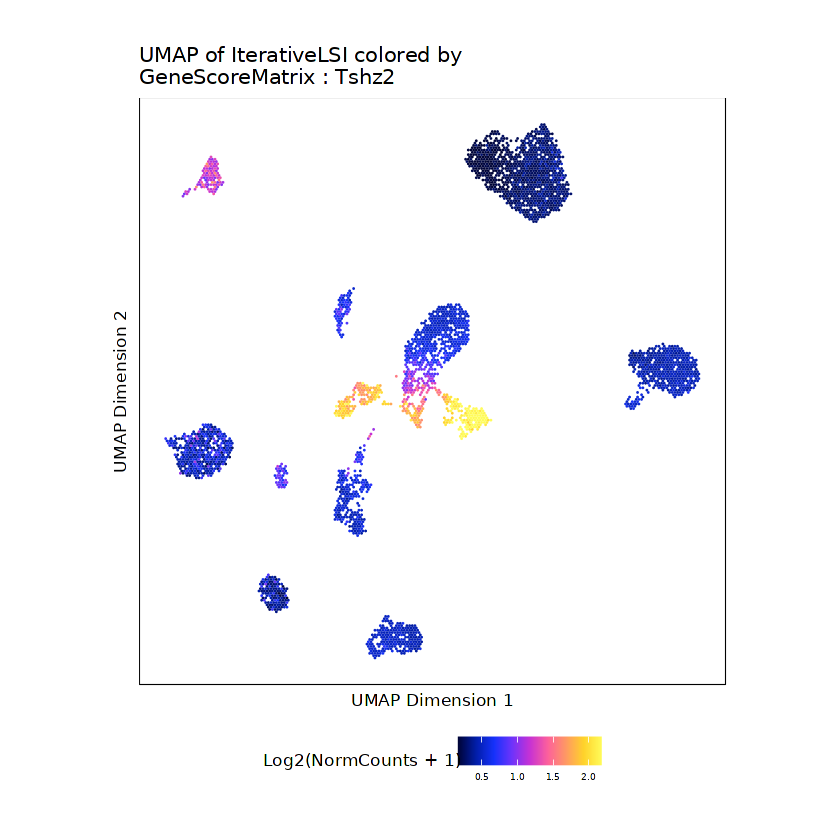

In [19]:
p <- plotEmbedding(
        ArchRProj = proj,
        colorBy = "GeneScoreMatrix",
        name = markerGenes,
        embedding = "UMAP",
        imputeWeights = getImputeWeights(proj)
    )

p$Tshz2

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”


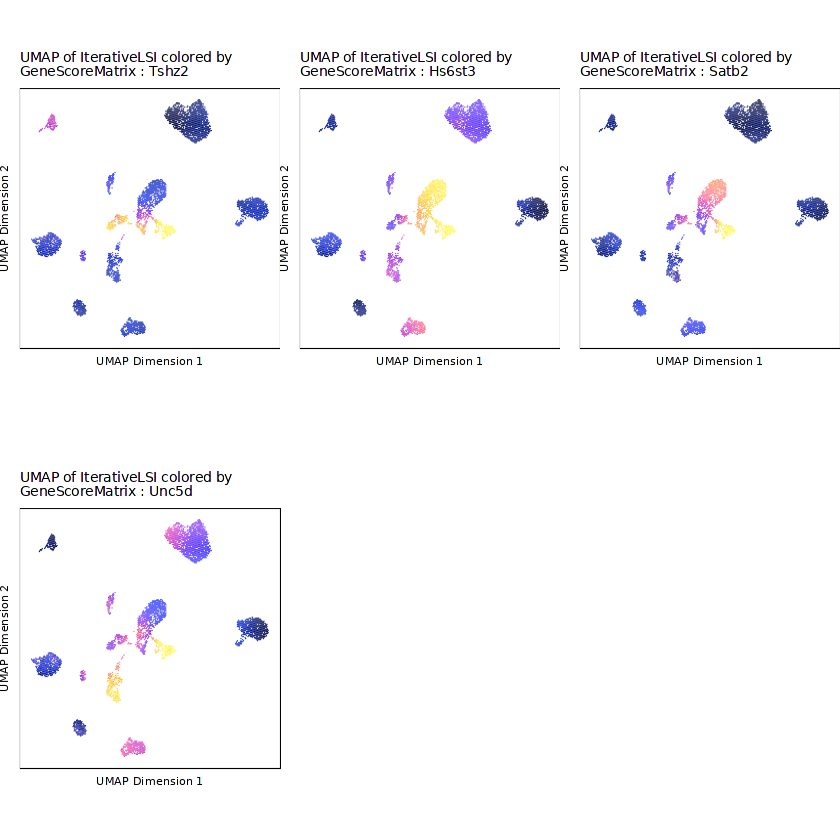

In [20]:
p2 <- lapply(p, function(x){
    x + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6.5) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
    theme(
        axis.text.x=element_blank(), 
        axis.ticks.x=element_blank(), 
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank()
    )
})
do.call(cowplot::plot_grid, c(list(ncol = 3),p2))

> If only I knew more about mice brains...

# RESPAWN 2

In [1]:
# So I don't have to make proj again
library(ArchR)
library(parallel)
library(Seurat)

library(pryr)
addArchRThreads(threads=36)
set.seed(1)

setwd("~/scRNA/arrowfiles/tutorialmm10")
ArrowFiles <- "beads_4000_1.arrow"
proj <- readRDS("backup.rds")


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

# Annotate cell type

## Get mouse cortex rna ref data.

> I was trying to use the mousecortexref data to do the annotation, but they are for the Azimuth package to use; took me quite a while to find out.  
> Also tried Seurat's FindTransferAnchors, but this requires both dataset to be of Seurat format.   
> The reference data comes from the Allen Institute.

In [2]:
ref <- readRDS("allen_brain.rds")
ref
ref <- FindVariableFeatures(
    ref,
    selection.method = "vst",
    nfeatures = 5000,
    verbose = FALSE
)
ref

An object of class Seurat 
34617 features across 14249 samples within 1 assay 
Active assay: RNA (34617 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

An object of class Seurat 
34617 features across 14249 samples within 1 assay 
Active assay: RNA (34617 features, 5000 variable features)
 2 dimensional reductions calculated: pca, umap

## Annotate using ref data

In [3]:
seRNA <- ref
seRNA@active.assay <- "RNA"

proj <- addGeneIntegrationMatrix(
    ArchRProj = proj,
    useMatrix = "GeneScoreMatrix",
    matrixName = "GeneIntegrationMatrix",
    reducedDims = "IterativeLSI",
    seRNA = seRNA,
    addToArrow = TRUE,
    groupRNA = "subclass",
    nameCell = "predictedsubCell",
    nameGroup = "predictedsubGroup",
    nameScore = "predictedsubScore",
    force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-771f7e14b736-Date-2022-08-30_Time-00-05-26.log
If there is an issue, please report to github with logFile!

2022-08-30 00:05:26 : Running Seurat's Integration Stuart* et al 2019, 0.001 mins elapsed.

2022-08-30 00:05:27 : Checking ATAC Input, 0.004 mins elapsed.

2022-08-30 00:05:27 : Checking RNA Input, 0.005 mins elapsed.

2022-08-30 00:05:37 : Found 19257 overlapping gene names from gene scores and rna matrix!, 0.177 mins elapsed.

2022-08-30 00:05:37 : Creating Integration Blocks, 0.177 mins elapsed.

2022-08-30 00:05:37 : Prepping Interation Data, 0.179 mins elapsed.

2022-08-30 00:05:38 : Computing Integration in 1 Integration Blocks!, 0 mins elapsed.

2022-08-30 00:05:38 : Block (1 of 1) : Computing Integration, 0 mins elapsed.

2022-08-30 00:05:50 : Block (1 of 1) : Identifying Variable Genes, 0.202 mins elapsed.

2022-08-30 00:06:08 : Block (1 of 1) : Getting GeneScoreMatrix, 0.504 mins elapsed.

2022-08-30 00:06:19 :

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-771f1ea35530-Date-2022-08-30_Time-00-15-52.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-771f1ea35530-Date-2022-08-30_Time-00-15-52.log



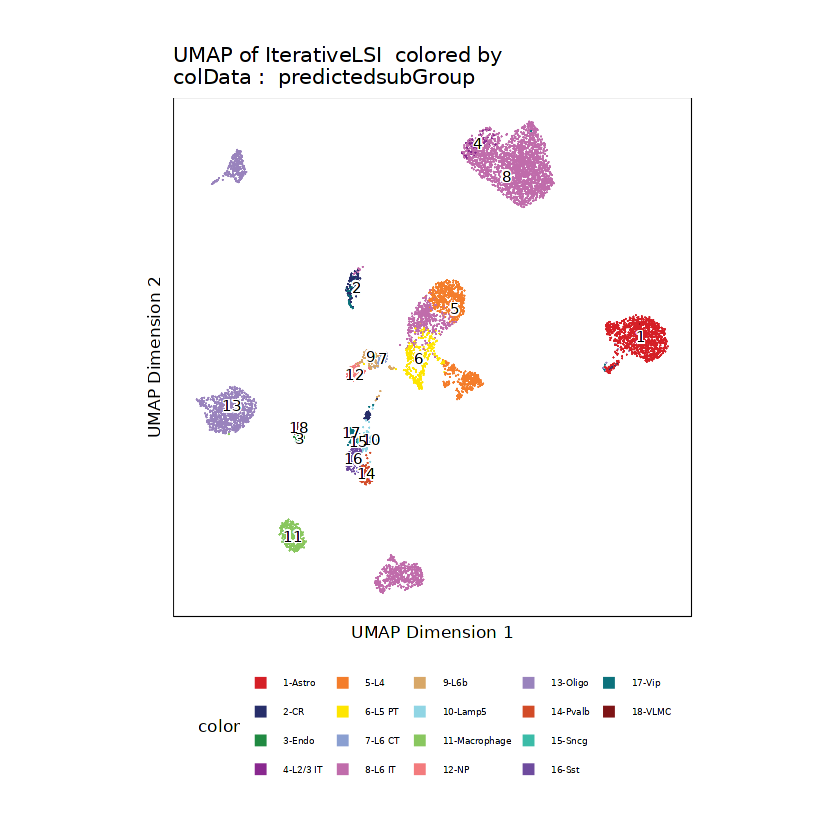

In [4]:
p3 <- plotEmbedding(
    proj,
    colorBy = "cellColData",
    name = "predictedsubGroup",
    embedding = "UMAP"
 )

p3

> The cell labeling passes visual judgement. Macrophages should be far away from astroglia cells. Neuronal cells are clustered together. However, there are two clusters not labeled. Perhaps they were not sequenced in the scRNA .

In [5]:
saveRDS(proj,"proj.rds")